# **K-Means Clustering Assignment By Rasha**

# KMeans Clustering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Dog Horse KMeans Challenge

In [2]:
# Import Data
df_dh = pd.read_csv("https://raw.githubusercontent.com/gumdropsteve/datasets/master/dog_or_horse.csv")
# We picked variables that we need
X = df_dh[['height', 'weight']]
df_dh.head()

,height,weight,target,type
0,27.0,71.0,0.0,dog
1,27.0,92.0,0.0,dog
2,32.0,47.0,0.0,dog
3,30.0,90.0,0.0,dog
4,28.0,91.0,0.0,dog


In [3]:
# Scale Data
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_dh_sc = sc.fit_transform(df_dh.drop('type',axis=1))

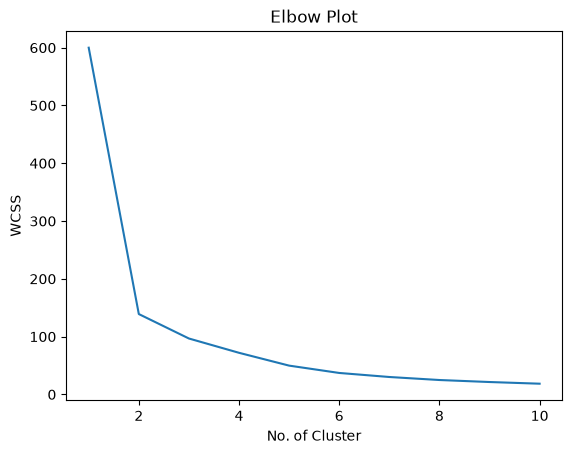

In [4]:
# Create Elbow Plot
from sklearn.cluster import KMeans
wcss=[]
for i in range(1,11):
    km=KMeans(n_clusters=i,random_state=42,n_init=10)
    km.fit(X_dh_sc)
    wcss.append(km.inertia_)
plt.plot(range(1,11),wcss)
plt.title('Elbow Plot')
plt.xlabel('No. of Cluster')
plt.ylabel('WCSS')
plt.show()

In [5]:
# Apply KMeans and Plot KMeans Results and Actual Results
kmeans=KMeans(n_clusters=2,random_state=42,n_init=10)
y_kmeans=kmeans.fit_predict(X_dh_sc)

In [6]:
print(y_kmeans)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [7]:
# Cluster centeriods
print (kmeans.cluster_centers_)

[[-0.84216798 -0.77166333 -1.        ]
 [ 0.84216798  0.77166333  1.        ]]


In [8]:
# assign the y_kmeans to a new column in the dataset
df_dh['kmean_prid']= y_kmeans
df_dh

,height,weight,target,type,kmean_prid
0,27.0,71.0,0.0,dog,0
1,27.0,92.0,0.0,dog,0
2,32.0,47.0,0.0,dog,0
3,30.0,90.0,0.0,dog,0
4,28.0,91.0,0.0,dog,0
...,...,...,...,...,...
195,55.0,140.0,1.0,horse,1
196,82.0,179.0,1.0,horse,1
197,46.0,132.0,1.0,horse,1
198,56.0,89.0,1.0,horse,1


### Plot the clusters including the centroid for each of the clusters as defined by K-Means

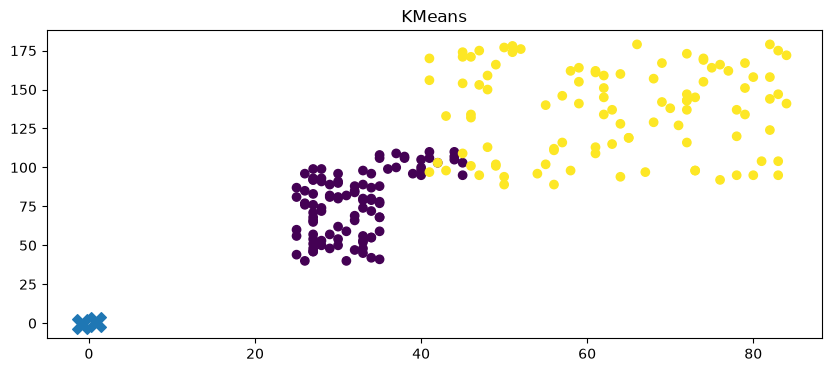

In [9]:
plt.figure(figsize=(10,4))
plt.scatter(df_dh.iloc[:,0],df_dh.iloc[:,1],c=df_dh['type'].map({'Dog':1,'Horse':0}))
plt.scatter(df_dh.iloc[:,0],df_dh.iloc[:,1],c=y_kmeans)
plt.scatter(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1],marker='X',s=200)
plt.title('KMeans')
plt.show()

In [10]:
df_dh['type']=df_dh['type'].map({'dog':0,'horse':1})

In [11]:
(df_dh['type']==df_dh['kmean_prid']).value_counts()

True    200
Name: count, dtype: int64

In [12]:
from sklearn.metrics import accuracy_score
accuracy_score(df_dh['type'],df_dh['kmean_prid'])*100

100.0

# Seattle Weather KMeans Challenge

In [13]:
df_sea = pd.read_csv("https://raw.githubusercontent.com/gumdropsteve/datasets/master/seattle_weather_1948-2017.csv")
X_sea = df_sea[['tmax', 'tmin']]
df_sea.head()

,ds,prcp,tmax,tmin,rain
0,1948-01-01,0.47,51,42,True
1,1948-01-02,0.59,45,36,True
2,1948-01-03,0.42,45,35,True
3,1948-01-04,0.31,45,34,True
4,1948-01-05,0.17,45,32,True


In [14]:
sc=StandardScaler()
X_sea_sc=sc.fit_transform(df_sea.drop('rain',axis=1).select_dtypes(include='number').fillna(0))

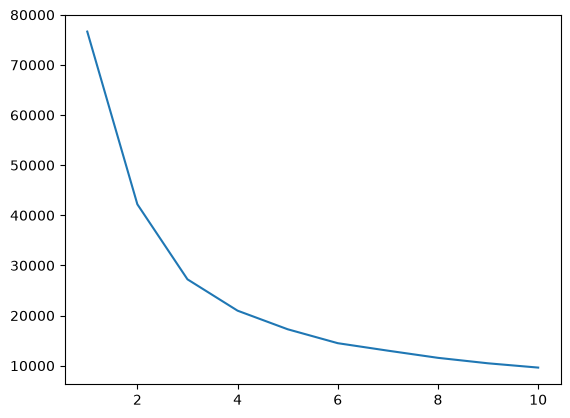

In [15]:
wcss=[]
for i in range(1,11):
    km=KMeans(n_clusters=i,random_state=42,n_init=10)
    km.fit(X_sea_sc)
    wcss.append(km.inertia_)
plt.plot(range(1,11),wcss)
plt.show()

In [16]:
kmeans=KMeans(n_clusters=2,random_state=42,n_init=10)
y_sea_kmeans=kmeans.fit_predict(X_sea_sc)

In [17]:
print(y_sea_kmeans)

[0 0 0 ... 0 0 0]


In [18]:
# assign the y_kmeans to a new column
df_sea['kmean_sea_prid']= y_sea_kmeans
df_sea

,ds,prcp,tmax,tmin,rain,kmean_sea_prid
0,1948-01-01,0.47,51,42,True,0
1,1948-01-02,0.59,45,36,True,0
2,1948-01-03,0.42,45,35,True,0
3,1948-01-04,0.31,45,34,True,0
4,1948-01-05,0.17,45,32,True,0
...,...,...,...,...,...,...
25546,2017-12-10,0.00,49,34,False,0
25547,2017-12-11,0.00,49,29,False,0
25548,2017-12-12,0.00,46,32,False,0
25549,2017-12-13,0.00,48,34,False,0


In [19]:
# replace True with 1 and False with 0 to help us caluclate the Accuracy Score
df_sea['rain'] = df_sea['rain'].map({True:1, False:0})

In [20]:
(df_sea['rain']==df_sea['kmean_sea_prid']).value_counts()

False    16945
True      8606
Name: count, dtype: int64

In [21]:
df_sea.dropna(subset = ['rain'], inplace=True)

In [22]:
df_sea['rain'].isna().sum()

np.int64(0)

### Plot the clusters including the centroid for each of the clusters as defined by K-Means

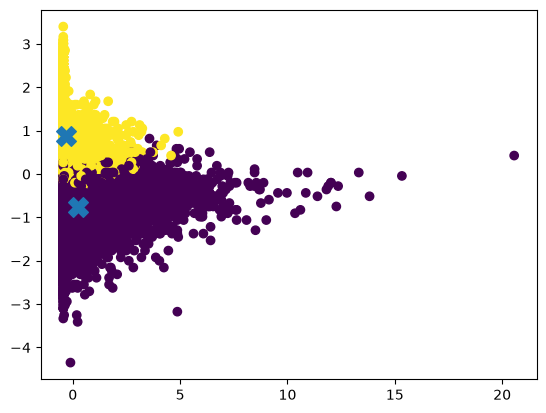

In [23]:
plt.scatter(X_sea_sc[:,0],X_sea_sc[:,1],c=y_sea_kmeans)
plt.scatter(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1],marker='X',s=200)
plt.show()

In [24]:
from sklearn.metrics import accuracy_score
accuracy_score(df_sea['rain'],df_sea['kmean_sea_prid'])*100

33.685611398152496

# Random Blob KMeans Challenge

- You dont have true labels for this data so this is truly an unsupervised dataset
- The blobs are randomly generated every time you run the cell and their characteristics are:
    - 2000-4000 data points
    - 10-30 blobs created

In [25]:
from sklearn.datasets import make_blobs
X,y=make_blobs(n_samples=300,centers=3,random_state=42)
df_blob=pd.DataFrame(X,columns=['X1','X2'])

In [26]:
from sklearn.preprocessing import StandardScaler
sc_blb=StandardScaler()
X_blb_sc=sc_blb.fit_transform(df_blob)

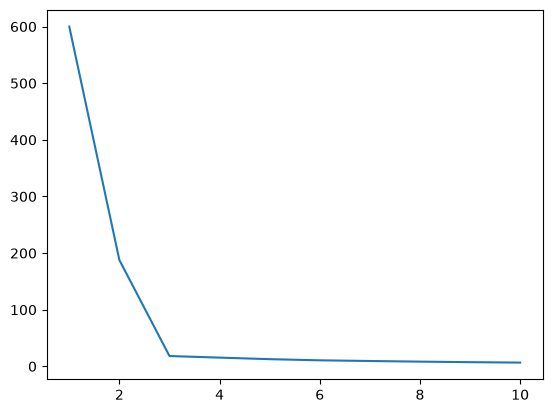

In [27]:
wcss=[]
for i in range(1,11):
    km=KMeans(n_clusters=i,random_state=42,n_init=10)
    km.fit(X_blb_sc)
    wcss.append(km.inertia_)
plt.plot(range(1,11),wcss)
plt.show()

In [28]:
kmeans=KMeans(n_clusters=3,random_state=42,n_init=10)
y_blb_kmeans=kmeans.fit_predict(X_blb_sc)

In [29]:
print(y_blb_kmeans)

[1 1 0 2 1 2 0 2 0 0 0 2 0 0 1 0 1 2 0 0 0 0 2 1 0 1 1 2 2 0 0 0 1 0 1 0 1
 2 1 2 2 0 1 2 0 0 1 2 1 2 2 1 1 0 1 2 1 0 2 0 1 2 2 1 1 2 2 1 1 0 2 1 1 0
 0 1 1 2 0 2 0 0 1 0 2 1 1 0 2 0 1 0 1 0 0 1 1 0 1 1 2 0 2 0 0 0 0 0 2 1 2
 0 0 0 0 2 1 2 1 2 2 2 0 1 1 1 1 0 1 1 0 0 0 0 0 2 2 1 0 1 0 0 1 0 2 2 2 0
 2 0 0 1 2 1 0 2 2 1 1 0 0 1 1 1 0 1 2 0 0 0 0 0 2 0 2 2 2 0 2 2 1 0 1 2 2
 1 2 0 2 2 1 1 2 1 2 2 2 2 0 1 0 0 2 2 0 2 1 1 2 0 0 1 2 2 1 1 1 1 0 1 1 2
 1 1 0 2 1 1 2 0 0 1 0 1 2 2 1 2 1 1 1 2 2 0 1 2 2 2 1 2 1 2 1 2 2 1 2 0 1
 0 0 0 1 0 2 2 1 2 2 0 0 2 2 2 1 1 1 0 0 0 2 2 2 2 1 2 1 2 2 1 0 2 2 0 1 0
 2 0 1 1]


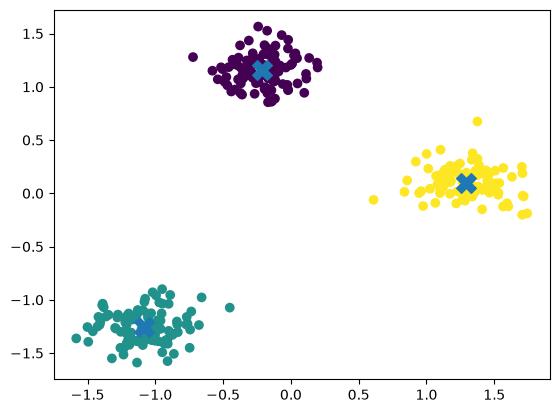

In [30]:
plt.scatter(X_blb_sc[:,0],X_blb_sc[:,1],c=y_blb_kmeans)
plt.scatter(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1],marker='X',s=200)
plt.show()